# IMPORT LIBRARIES

In [1]:
import mat73
import io, os, random
import numpy as np
import time
import math
import pickle
from matplotlib import pyplot as plt
from IPython.display import clear_output
from scipy.signal import spectrogram
import gc

Set a seed in order to ensure reproducibility

In [2]:
np.random.seed(2026)

Function for opening a MAT file

In [3]:
def load_mat_file(matlab_path, file_name):
    # Load the .mat file
    data_dict = mat73.loadmat(matlab_path + file_name)

    # Automatically get the name of the first variable (key) in the .mat file
    data_keys = list(data_dict.keys())
    if data_keys:  # Check if the list is not empty
        data_key = data_keys[0]  # Take the first key as the main variable name
        complex_data = data_dict[data_key]

        # Convert 'complex_data' from 64-bit complex to 32-bit complex
        complex_data = complex_data.astype(np.complex64)

        # Check and display information about 'complex_data'
        print(f"Variable: {data_key}")
        print(f"Data type after conversion: {type(complex_data)}")
        print(f"Data shape: {complex_data.shape}")
        bits_per_element = complex_data.dtype.itemsize * 8
        print(f"Size of each element in bits after conversion: {bits_per_element}")
        return complex_data
    else:
        print("The .mat file does not contain variables.")
        return None


Open a MAT file and assign the complex samples in a variable

In [ ]:
# Defines the path to the .mat file.
matlab_path = '/mnt/c/Users/ariel/Downloads/'
file_name = "LoRa_SF07_v1.mat"


# Loads the .mat file, gets the first variable, converts the data to 32-bit complex, and stores it in 'complex_data'.
complex_data = load_mat_file(matlab_path, file_name)

Exception ignored in: <function WeakValueDictionary.__init__.<locals>.remove at 0x7015282a1080>
Traceback (most recent call last):
  File "/usr/lib/python3.12/weakref.py", line 105, in remove
    def remove(wr, selfref=ref(self), _atomic_removal=_remove_dead_weakref):

KeyboardInterrupt: 


Plot samples to check if the signal has been imported succesfully

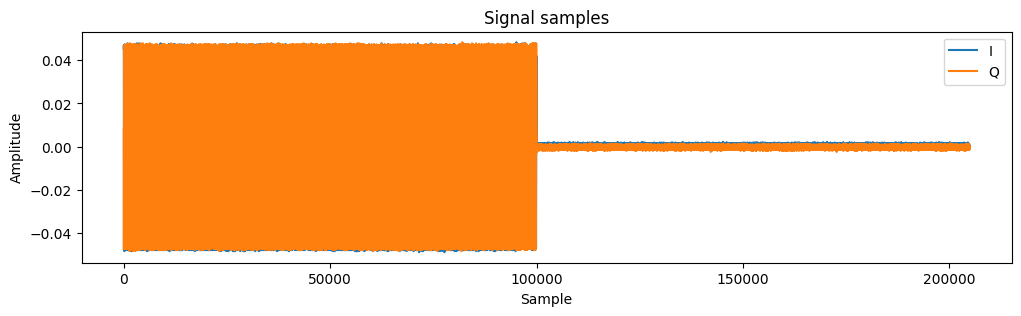

In [ ]:
plt.figure(figsize=(12,3))
plt.plot(np.real(complex_data[:204800]), label="I")  # Plot the real part of the first 1000 samples
plt.plot(np.imag(complex_data[:204800]), label="Q")  # Plot the imaginary part of the first 1000 samples
plt.title("Signal samples")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

Plot the amplitude of every sample from the signal. This way we can define a threshold which will be useful to remove the silences between packets

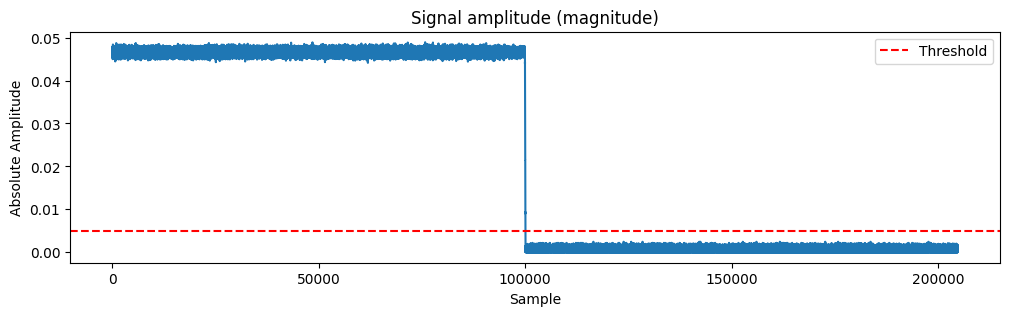

In [ ]:
plt.figure(figsize=(12,3))
plt.plot(np.abs(complex_data[:204800]))  # Plot the magnitude of the first 204800 samples
plt.axhline(y=0.005, color='r', linestyle='--', label='Threshold')
plt.title("Signal amplitude (magnitude)")
plt.xlabel("Sample")
plt.ylabel("Absolute Amplitude")
plt.legend()
plt.show()

Defining a function to remove the silences, based on the previous threshold (0.005)

In [ ]:
def filter_signal_by_threshold(signal, threshold):
    # Create a boolean mask where the condition is met
    mask = np.abs(signal) > threshold
    # Apply the mask to the signal to filter it
    filtered_signal = signal[mask]
    return filtered_signal

Applying the function, let's see how many samples remained after removing the null ones.

In [ ]:
reduced_signal = filter_signal_by_threshold(complex_data, 0.005)
print(f"Original signal length: {len(complex_data)}")
print(f"Filtered signal length: {len(reduced_signal)}")
del complex_data
gc.collect()

Original signal length: 240000000
Filtered signal length: 117224979


6790

The next functions are aimed at:
* **sigfilt**: Filtering the signal to the known bandwidth (These LoRa signals have 125 kHz of BW). The idea is to remove the residual noise from the undesired band, since these samples were recorded at the sampling rate of 2 MHz.
* **slice_signal_into_chunks**: Slicing the signal into smaller parts, so they'll meet the length we saw for the RadioML 2018A dataset.
* **select_random_chunks**: Picking a certain amount of blocks (chunks), in order to avoid sequential dependency (it might bias the training process later on). According to the RadioML dataset, there were 4096 'frames' per class.  

In [ ]:
from scipy.signal import butter, filtfilt

def sigfilt(x, bw, alpha=1.1, fs=2e6, order=5):
    
    nyq = fs / 2
    cutoff = (bw * alpha) / 2
    norm_cutoff = cutoff / nyq

    b, a = butter(order, norm_cutoff, btype='low')
    y = filtfilt(b, a, x)
    return y

def slice_signal_into_chunks(signal, chunk_size):
    # Calculate the number of chunks
    num_chunks = len(signal) // chunk_size
    # Slice the signal into chunks
    chunks = [signal[i*chunk_size:(i+1)*chunk_size] for i in range(num_chunks)]
    return chunks
    
def select_random_chunks(chunks, num_chunks_to_select):
    # Randomly select the specified number of chunks
    selected_chunks = np.random.choice(len(chunks), size=num_chunks_to_select, replace=False)
    return np.array([chunks[i] for i in selected_chunks])

Just to prove with the current file, the signal will be divided in chunks of size 1024, and from the resulting amount of chunks, 1000 of them will be picked randomly (The random seed was set, so a new execution should select the same samples)

In [ ]:
#filtered_signal = sigfilt(reduced_signal, bw=125e3, alpha=1.1, fs=2e6, order=5)
chunk_size = 1024
chunks = slice_signal_into_chunks(reduced_signal, chunk_size)
num_chunks_to_select = 1000
selected_chunks = select_random_chunks(chunks, num_chunks_to_select)

For the selected chunks, the low-pass filter is applied.

In [ ]:
filtered_chunks = np.array([sigfilt(chunk, bw=125e3, alpha=1.1, fs=2e6, order=5) for chunk in selected_chunks])

This function provide the FFT of a single chunk, representing it in the frequency domain. (Visualization purposes)

In [ ]:
def get_fft(signal, fs, nfft=1024):
    fft = np.fft.fft(signal, n=nfft)
    fft = np.fft.fftshift(fft)  # Shift the zero frequency component to the center
    fft_freqs = np.fft.fftfreq(nfft, d=1/fs)
    fft_freqs = np.fft.fftshift(fft_freqs)  # Shift the frequency axis to the center
    return fft, fft_freqs

Plot a non-filtered chunk in Time and Frequency domain to see its properties.

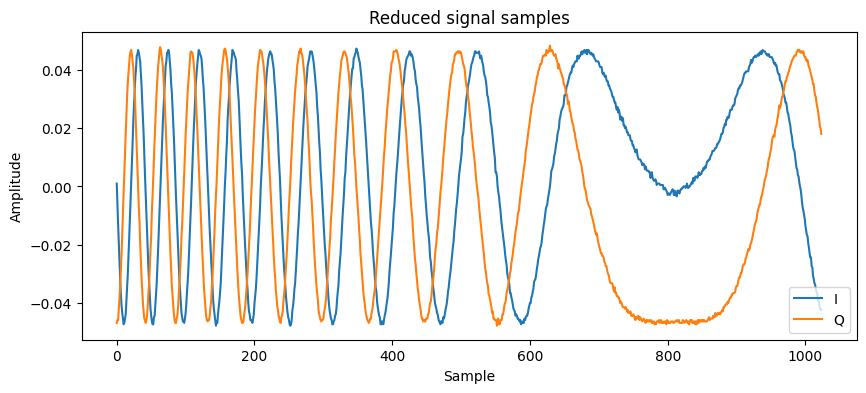

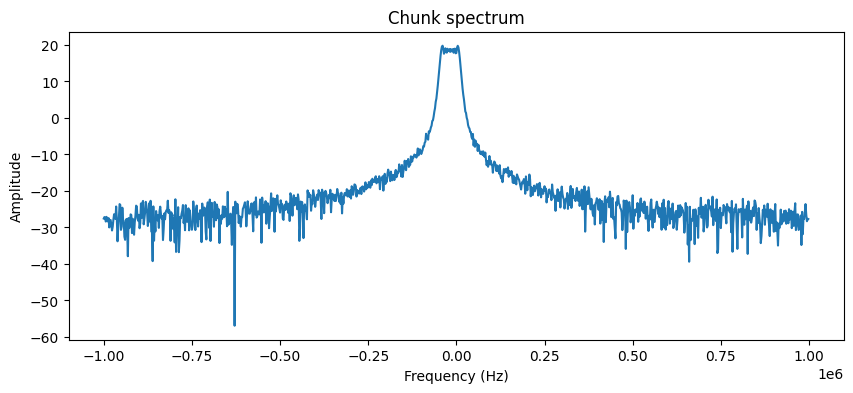

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(np.real(selected_chunks[10]), label="I")  # Plot the real part of the first 2048 samples
plt.plot(np.imag(selected_chunks[10]), label="Q")  # Plot the imaginary part of the first 2048 samples
plt.title("Reduced signal samples")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.show()
fft, freqs = get_fft(selected_chunks[10], fs=2e6, nfft=1024)
plt.figure(figsize=(10, 4))
plt.plot(freqs, 20 * np.log10(np.abs(fft)))
plt.title("Chunk spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.show()

Plot the same chunk after it has been filtered.

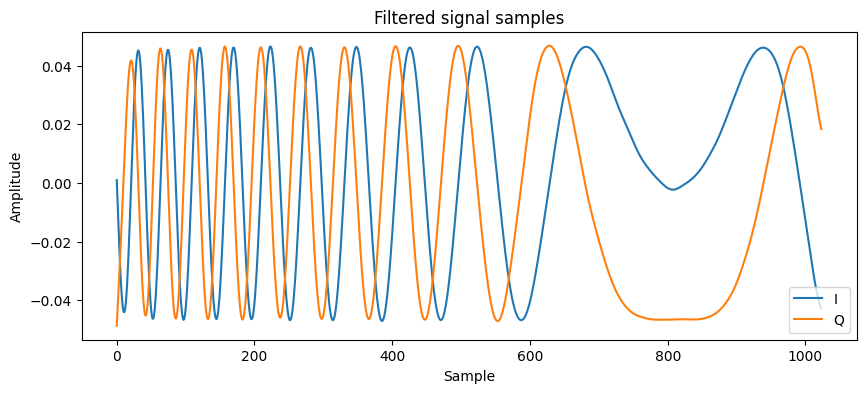

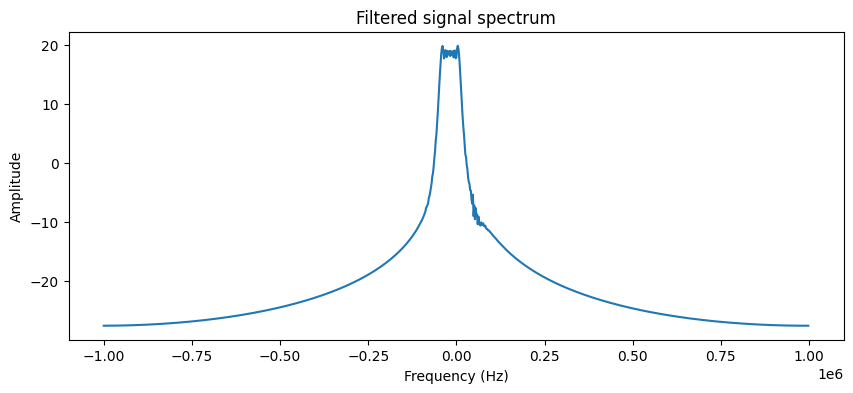

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(np.real(filtered_chunks[10]), label="I")  # Plot the real part of the first 1000000 samples
plt.plot(np.imag(filtered_chunks[10]), label="Q")  # Plot the imaginary part of the first 1000000 samples
plt.title("Filtered signal samples")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.show()
fft, freqs = get_fft(filtered_chunks[10], fs=2e6, nfft=1024)
plt.figure(figsize=(10, 4))
plt.plot(freqs, 20 * np.log10(np.abs(fft)))
plt.title("Filtered signal spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.show()

## All signals at once

The idea here is to apply the previous processes to each MAT file. The result is a NPY file per signal class. For instance, LoRa_SF07_v1.mat generates a LoRa_SF07_v1_filtered_chunks.npy file

In [ ]:
# Defines the path to the .mat file.
matlab_path = '/mnt/c/Users/ariel/Downloads/'
file_names = ["LoRa_SF07_v1.mat", "LoRa_SF08_v1.mat", "LoRa_SF09_v1.mat", "LoRa_SF10_v1.mat", "LoRa_SF11_v1.mat", "LoRa_SF12_v1.mat"]

chunk_size = 1024
num_chunks_to_select = 4096
for filename in file_names:
    complex_data = load_mat_file(matlab_path, filename)
    reduced_signal = filter_signal_by_threshold(complex_data, 0.005)
    print(f"Original signal length: {len(complex_data)}")
    print(f"Filtered signal length: {len(reduced_signal)}")
    del complex_data
    gc.collect()
    chunks = slice_signal_into_chunks(reduced_signal, chunk_size)
    selected_chunks = select_random_chunks(chunks, num_chunks_to_select)
    filtered_hunks = np.array([sigfilt(chunk, bw=125e3, alpha=1.1, fs=2e6, order=5) for chunk in selected_chunks])
    filename_chunks = filename.split('.')[0]
    np.save(f"{filename_chunks}_filtered_chunks.npy", filtered_hunks)

Variable: LoRa_SF07_v1
Data type after conversion: <class 'numpy.ndarray'>
Data shape: (240000000,)
Size of each element in bits after conversion: 64
Original signal length: 240000000
Filtered signal length: 117224979
Variable: LoRa_SF08_v1
Data type after conversion: <class 'numpy.ndarray'>
Data shape: (240000000,)
Size of each element in bits after conversion: 64
Original signal length: 240000000
Filtered signal length: 103352945
Variable: LoRa_SF09_v1
Data type after conversion: <class 'numpy.ndarray'>
Data shape: (240000000,)
Size of each element in bits after conversion: 64
Original signal length: 240000000
Filtered signal length: 123081360
Variable: LoRa_SF10_v1
Data type after conversion: <class 'numpy.ndarray'>
Data shape: (240000000,)
Size of each element in bits after conversion: 64
Original signal length: 240000000
Filtered signal length: 128181417
Variable: LoRa_SF11_v1
Data type after conversion: <class 'numpy.ndarray'>
Data shape: (240000000,)
Size of each element in bits